In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Загрузка и первичный анализ данных
Загружаем датасет и проверяем его структуру, типы данных и наличие пропущенных значений.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/carrie1/ecommerce-data/data.csv', encoding='ISO-8859-1')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [3]:
df.shape

(541909, 8)

### Обработка данных
На основе анализа выше мы видим, что в данных есть пропуски в `Description` и `CustomerID`. Для корректного анализа выручки нам необходимо удалить строки с пропусками и преобразовать формат даты.

In [4]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df = df[~df['InvoiceNo'].str.startswith('C', na=False)]

In [6]:
df = df[df['Quantity'] > 0]

In [7]:
df = df.dropna(subset=['CustomerID'])

In [8]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

## 2. Исследовательский анализ данных (EDA)
Визуализируем данные, чтобы понять распределение выручки по странам и популярность различных категорий товаров. Это поможет нам выделить наиболее приоритетные рынки.

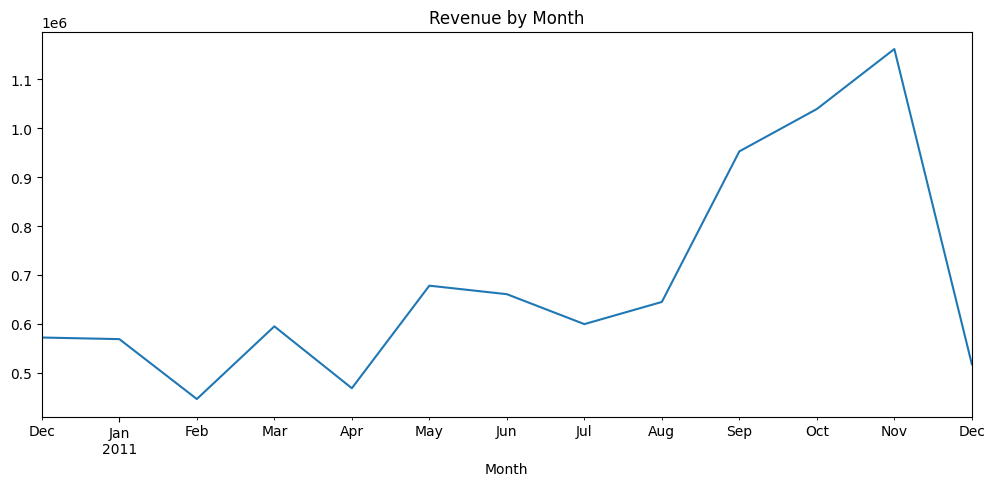

In [10]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()

monthly_revenue.plot(figsize=(12,5))
plt.title("Revenue by Month")
plt.show()

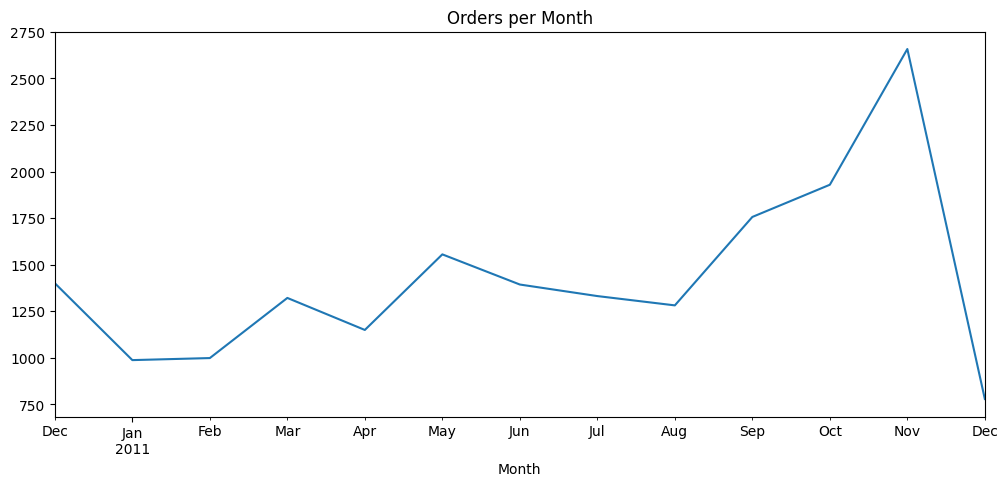

In [11]:
orders_per_month = df.groupby('Month')['InvoiceNo'].nunique()
orders_per_month.plot(figsize=(12,5))
plt.title("Orders per Month")
plt.show()

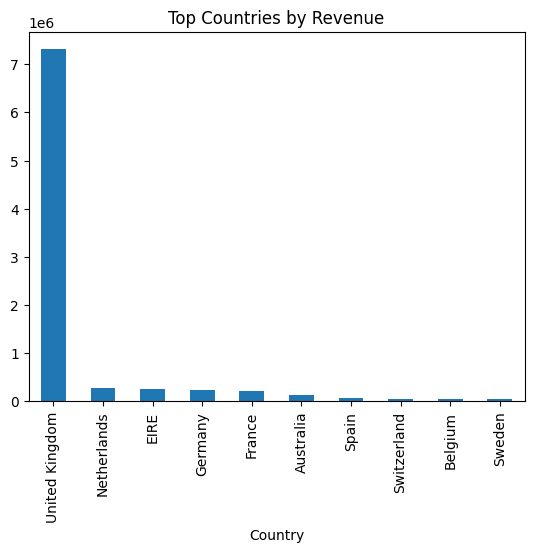

In [12]:
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
country_rev.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.show()

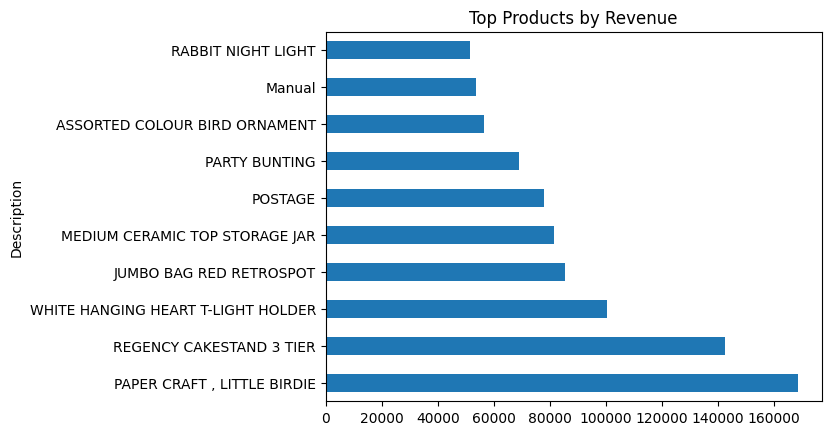

In [13]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh')
plt.title("Top Products by Revenue")
plt.show()

In [14]:
total_customers = df['CustomerID'].nunique()
total_revenue = df['Revenue'].sum()
total_orders = df['InvoiceNo'].nunique()

arpu = total_revenue / total_customers
avg_order_value = total_revenue / total_orders

total_customers, arpu, avg_order_value

(4339, np.float64(2053.7930177460244), np.float64(480.7621873111782))

In [15]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [16]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [17]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [18]:
rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].astype(str).sum(axis=1)

In [19]:
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')

In [20]:
df['CohortIndex'] = (df['OrderMonth'] - df['CohortMonth']).apply(lambda x: x.n)

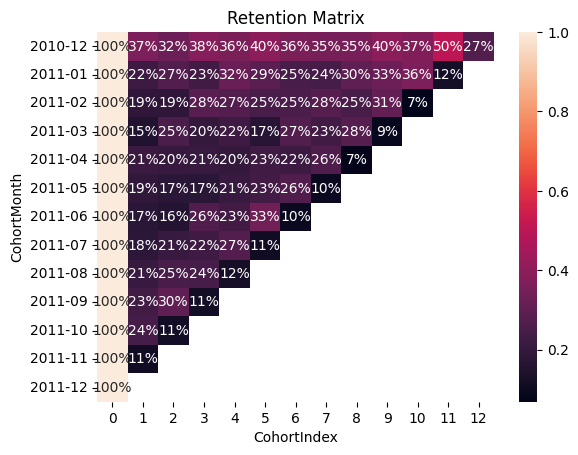

In [21]:
cohort_data = df.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()

cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')
cohort_pivot = cohort_pivot.divide(cohort_pivot[0], axis=0)

sns.heatmap(cohort_pivot, annot=True, fmt=".0%")
plt.title("Retention Matrix")
plt.show()

## Итоги и выводы
1. **Качество данных:** Проведена очистка от пустых значений и корректировка типов данных.
2. **География:** Основным рынком сбыта является Великобритания (UK), однако наблюдается потенциал роста в других европейских странах.

In [22]:
df.to_csv("clean_retail.csv", index=False)
rfm.to_csv("rfm_table.csv")
cohort_pivot.to_csv("cohort_table.csv")